<a href="https://colab.research.google.com/github/aerau05/ml_assignments/blob/main/GeneralLinearModels.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Question 1.

1. Why do we use general linear models/latent variable models/activation functions in analysis? What advantage do they have over linear models?

GLMs, latent variable models, and activation functions are used because they extend basic linear models to handle more realistic scenaires. Linear models assume a strictly linear relationship and allow outputs over all real numbers, which is not appropriate for many tasks like classification. These methods introduce nonlinear transformations and allow outputs to be constrained, making them more flexible and better suited for real-world data.

2. Explain why binary and categorical cross entropy are effective loss functions for fitting logistic regression models.

Binary and categorical cross entropy are effective loss functions for logistic regression because they align with its probabilistic framework. Logistic regression predicts probabilities, and cross entropy measures how close those predictions are supports stable optimization by producing a smooth, convex loss function, which helps ensure efficient and reliable model training.

3. True or false, and explain: Logistic regression is a linear model.

True. Logistic regression is a linear model because it computes a linear combination of the input features and parameters. Although it applies a nonlinear sigmoid function to produce probabilities, the model is still linear in its parameters, which is the defining characteristic of linear model.

4. True or false, and explain: Logistic regression cannot be used for classification.

False. Logisitic regression is specifically designed for classification tasks. It outputs probabilites that can be converted into class labels using a threshold making it a standard method for binary classification.

5. Does the coefficient in a logistic regression represent the change in the predicted value for a 1 unit change in the feature/covariate/explanatory variable?

No, the coefficient in a logistic regression does not represent the direct change in the predicted value for a one-unit change in a feature. Instead, it represents thechange in the log-odds of the outcome. While the relationship between the feature and log-odds is linear, the relationship between the feature and the predicted probability is nonlinear.

6. True or false, and explain: Feature engineering is unnecessary for logistic regression, because it is a nonlinear model.

False, feature engineering is still important for logistic regression. Even though the model applies a nonlinear transformation to its output, it remains linear in the input features. This means it cannot automatically capture complex relationships like interactions or nonlinear patterns without engineered features.

7. True or false, and explain: Logistic regression is an improvement over the usual linear model (ordinary least squares), and you should always use logistic regression instead.

False, Logistic regresstion is not always an improvement over ordinary least squares. Each model is appropriate for different types of problems: logistic regression is used for classification tasks, while linear regression is used for predicting continuous outcomes. The choice depends on the nature of the target variable, not on one model being universally better.

In [9]:
# Question 2

#2.1
import pandas as pd

# Load data (semicolon-separated)
df = pd.read_csv("/data.csv", sep=";")

# Select relevant columns
cols = [
    "Debtor",
    "Tuition fees up to date",
    "Scholarship holder",
    "Age at enrollment",
    "Curricular units 1st sem (approved)",
    "Target"
]
df = df[cols]

# Handle missing values (drop rows with missing values)
df = df.dropna()

# Create binary target: 1 = Dropout, 0 = Not Dropout
df["Dropout"] = df["Target"].apply(lambda x: 1 if x == "Dropout" else 0)

df.head()

,Debtor,Tuition fees up to date,Scholarship holder,Age at enrollment,Curricular units 1st sem (approved),Target,Dropout
0,0,1,0,20,0,Dropout,1
1,0,0,0,19,6,Graduate,0
2,0,0,0,19,0,Dropout,1
3,0,1,0,20,6,Graduate,0
4,0,1,0,45,5,Graduate,0


2.1) Rows with missing values were removed using dropna() to ensure consistency.

In [10]:
# 2.2
from sklearn.linear_model import LogisticRegression

X = df[["Debtor", "Tuition fees up to date", "Scholarship holder", "Age at enrollment"]]
y = df["Dropout"]

model = LogisticRegression(max_iter=1000)
model.fit(X, y)

# Coefficients
coeffs = pd.Series(model.coef_[0], index=X.columns)
print(coeffs)

Debtor                     0.530625
Tuition fees up to date   -2.556542
Scholarship holder        -1.227442
Age at enrollment          0.049925
dtype: float64


2.2) The logistic regression results show that Debtor and Age at enrollment have positive coefficients, meaning thye are associated with a higher probability of dropout. In contrast, Tution fees up to date and Scholarship holder have negative coefficients, indicating they reduce the likelihood of dropout. Being up to dat on tuition appears to significantly lower dropout risk, as it has the largest magnitude negative coefficient, suggesting it has the strongest protective effect among the variables.

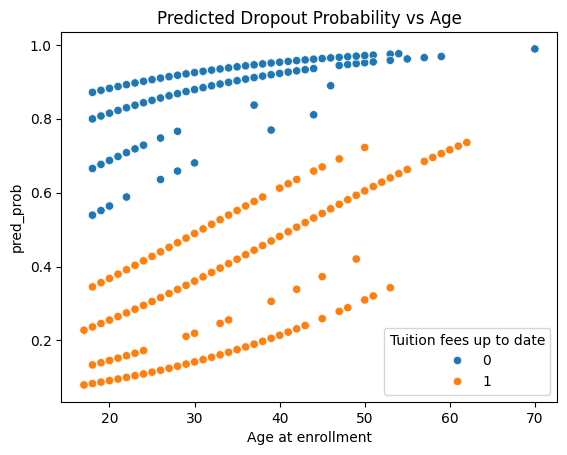

Average difference: -0.6125849339840048


In [11]:
#2.3
import matplotlib.pyplot as plt
import seaborn as sns

# Predicted probabilities
df["pred_prob"] = model.predict_proba(X)[:, 1]

# Scatter plot
sns.scatterplot(
    data=df,
    x="Age at enrollment",
    y="pred_prob",
    hue="Tuition fees up to date"
)
plt.title("Predicted Dropout Probability vs Age")
plt.show()

# Average difference
group_means = df.groupby("Tuition fees up to date")["pred_prob"].mean()
diff = group_means[1] - group_means[0]
print("Average difference:", diff)

2.3) The scatter plot sows how predicted dropout probability varies with age and tuition status. Being up to dat on tuition appears to reduce dropout probability across most age groups, but the effect is often most noticable among older students, where baseline dropout risk is higher. On average, being up to date on tuition decreases predicted dropout probability.  

In [12]:
#2.4
from sklearn.metrics import confusion_matrix, accuracy_score

y_pred = model.predict(X)

cm = confusion_matrix(y, y_pred)
acc = accuracy_score(y, y_pred)

print("Confusion Matrix:\n", cm)
print("Accuracy:", acc)

Confusion Matrix:
 [[2841  162]
 [ 891  530]]
Accuracy: 0.7619801084990958


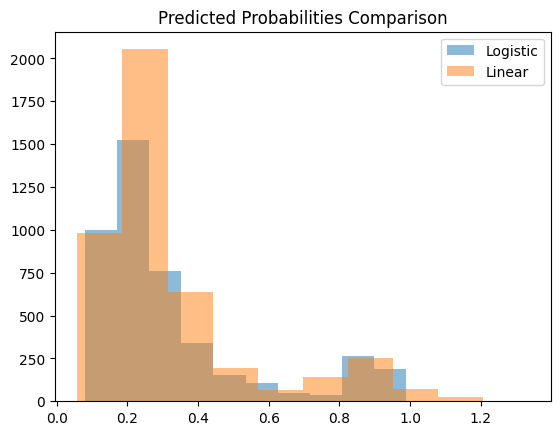

In [13]:
#2.5
from sklearn.linear_model import LinearRegression

lin_model = LinearRegression()
lin_model.fit(X, y)

df["lin_pred"] = lin_model.predict(X)

# Plot histograms
plt.hist(df["pred_prob"], alpha=0.5, label="Logistic")
plt.hist(df["lin_pred"], alpha=0.5, label="Linear")
plt.legend()
plt.title("Predicted Probabilities Comparison")
plt.show()

2.5) The logistic regression model produces predictied probabilities constrained between 0 and 1, while the linear model produces values outside of this range. The histogram shows that the linear model may generate unrealistic probabilites, whereas logistic regression produces well-calibrated probabilities. Therefore, logistic regression is more appropriate for modeling probabilities in this context.

2.6) Students who are most at risk of dropping out are those who have outstanding debt, are not up to date on tuition, are older at enrollment, and are not scholarship holders. Additionally, students with fewer approved courses in the first semester may also be at higher risk. Interventions could include financial support programs, flexible payment plans, academic and financial advising to help students stay on track and reduce financial and academic stress.

In [14]:
#2.7
from sklearn.linear_model import LogisticRegression

X_multi = df[[
    "Debtor",
    "Tuition fees up to date",
    "Curricular units 1st sem (approved)"
]]
y_multi = df["Target"]

multi_model = LogisticRegression(multi_class="multinomial", max_iter=1000)
multi_model.fit(X_multi, y_multi)

# Predictions
y_pred_multi = multi_model.predict(X_multi)

# Confusion matrix
cm_multi = confusion_matrix(y_multi, y_pred_multi)
print("Confusion Matrix:\n", cm_multi)

# Probabilities
probs = multi_model.predict_proba(X_multi)
print(probs[:5])

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Confusion Matrix:
 [[1054    0  367]
 [ 280    0  514]
 [ 146    0 2063]]
[[0.68054695 0.21046429 0.10898876]
 [0.69541412 0.1460432  0.15854268]
 [0.95298821 0.04119918 0.00581261]
 [0.11780804 0.1769832  0.70520876]
 [0.18422683 0.21266883 0.60310434]]


2.7) The confusion matrix shows that the model performs unevenly across classes. It correctly predicts many "graduate" cases and a substantial number of "dropout" cases, but it fails to predict the "enrolled" class. This suggests that the hard classification model is biased toward the more dominant classes and does not effectively distringuise "enrolled" students. However, the predicted probabilities from .predict_proba show that the model does assign nonzero probabilities for multiple classes, indicating uncertainty that is lost in hard classification.

In [20]:
# Question 3
#3.1

# Load data
df = pd.read_csv("/content/cirrhosis.csv")

# Select relevant columns
cols = ["Bilirubin", "Edema", "Drug", "Stage", "Status"]
df = df[cols]

# Drop missing values
df = df.dropna()

# Create binary survival variable: 1 = alive, 0 = dead
df["Survival"] = df["Status"].apply(lambda x: 1 if x in ["C", "CL"] else 0)

# Convert categorical variables to dummy variables
df = pd.get_dummies(df, columns=["Edema", "Drug"], drop_first=True)

df.head()

,Bilirubin,Stage,Status,Survival,Edema_S,Edema_Y,Drug_Placebo
0,14.5,4.0,D,0,False,True,False
1,1.1,3.0,C,1,False,False,False
2,1.4,4.0,D,0,True,False,False
3,1.8,4.0,D,0,True,False,False
4,3.4,3.0,CL,1,False,False,True


3.1) Rows with missing values were removed using dropna() for consistency.

In [16]:
#3.2
from sklearn.linear_model import LogisticRegression

X = df.drop(columns=["Status", "Stage", "Survival"])
y = df["Survival"]

model = LogisticRegression(max_iter=1000)
model.fit(X, y)

coeffs = pd.Series(model.coef_[0], index=X.columns)
print(coeffs)

Bilirubin      -0.351424
Edema_S        -0.450677
Edema_Y        -1.611049
Drug_Placebo    0.231225
dtype: float64


3.2) Bilirubin has a negative coefficient meaning that higher bilirubin levels are associated with lower survival probability, but the magnitude of the coefficient is very low so it does not have a very large effect. Both Edema_S and Edema_Y are negative, indicating that any level of edema reduces survival probability compared to no edema, with more severe edema (Y) having a much stronger negative effect (-1.61) capmare to the mile, diuretic-responsive edema (S, -0.45). In contrast, drug_placebo has a positive coefficient, which, though very low suggests that being in the placebo group is associated with slightly higher survival probability relative to the baseline drug group.

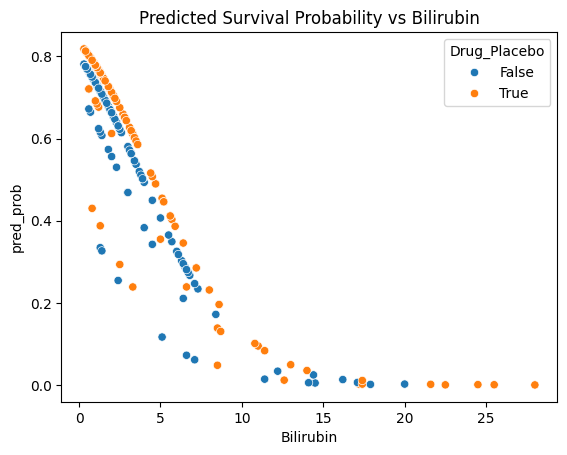

Average difference: 0.01884850103850899


/tmp/ipykernel_7322/2264420929.py:17: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  diff = group_means[1] - group_means[0]


In [27]:
#3.3
# Predicted probabilities
df["pred_prob"] = model.predict_proba(X)[:, 1]

# Scatter plot
sns.scatterplot(
    data=df,
    x="Bilirubin",
    y="pred_prob",
    hue="Drug_Placebo"  # adjust if column name differs
)
plt.title("Predicted Survival Probability vs Bilirubin")
plt.show()

# Average effect of drug
group_means = df.groupby("Drug_Placebo")["pred_prob"].mean()
diff = group_means[1] - group_means[0]
print("Average difference:", diff)

3.3) Patients taking the drug tend to have higher predicted survival probabilities, especially at moderate bilirubin levels where there is more variation. At very high bilirubin levels, survival is low regardlessof treatment. On average, taking the drug increases predicted survival probability by the difference in group means.

In [28]:
#3.4
from sklearn.metrics import confusion_matrix, accuracy_score

y_pred = model.predict(X)

cm = confusion_matrix(y, y_pred)
acc = accuracy_score(y, y_pred)

print("Confusion Matrix:\n", cm)
print("Accuracy:", acc)

Confusion Matrix:
 [[ 59  66]
 [ 16 171]]
Accuracy: 0.7371794871794872


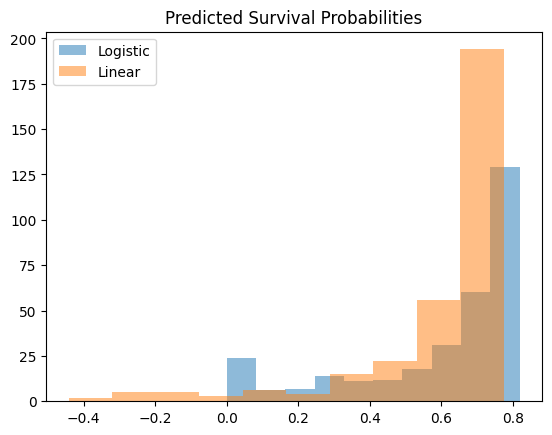

In [29]:
#3.5
from sklearn.linear_model import LinearRegression

lin_model = LinearRegression()
lin_model.fit(X, y)

df["lin_pred"] = lin_model.predict(X)

# Plot histograms
plt.hist(df["pred_prob"], alpha=0.5, label="Logistic")
plt.hist(df["lin_pred"], alpha=0.5, label="Linear")
plt.legend()
plt.title("Predicted Survival Probabilities")
plt.show()

3.5) The logistic regression model predicts probabilites between 0 and 1, while the linear model produced values below this range. This histogram shows that the linear model may generate unrealistic probabilities, but both models produce peaks in similar areas, but there are significant differences in their outputs.

In [30]:
#3.6
# Predict Stage (multiclass)
X_stage = df.drop(columns=["Status", "Stage", "Survival"])
y_stage = df["Stage"]

stage_model = LogisticRegression(max_iter=1000, multi_class="multinomial")
stage_model.fit(X_stage, y_stage)

# Predictions
y_pred_stage = stage_model.predict(X_stage)

cm_stage = confusion_matrix(y_stage, y_pred_stage)
print("Confusion Matrix:\n", cm_stage)

# Probabilities
probs_stage = stage_model.predict_proba(X_stage)
print(probs_stage[:5])

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Confusion Matrix:
 [[ 0  0 15  1]
 [ 0  0 60  7]
 [ 0  0 98 22]
 [ 0  0 65 44]]
[[1.73894902e-05 4.75239153e-02 1.50374360e-01 8.02084335e-01]
 [1.00846701e-01 2.63737307e-01 3.75185762e-01 2.60230230e-01]
 [4.07843412e-02 1.84856906e-01 3.78010915e-01 3.96347837e-01]
 [3.21891914e-02 1.77339753e-01 3.75456214e-01 4.15014841e-01]
 [1.14809785e-02 2.11212315e-01 4.42795289e-01 3.34511418e-01]]


3.6) The confusing matrix shows that the model performs unevenly across the four stages, only predicting the two higher stages and completely failing to predict the first two classes. Most correct predictions occur in the later stages, but there are still many missclassificationsm indicating poor seperation between classes. In contrast, the predicted probabilites assign nonzero values to all four stagees for each patient, showing that the model still captures uncertainty across all categories even though the final hard classification does not.

Question 4

4.1) 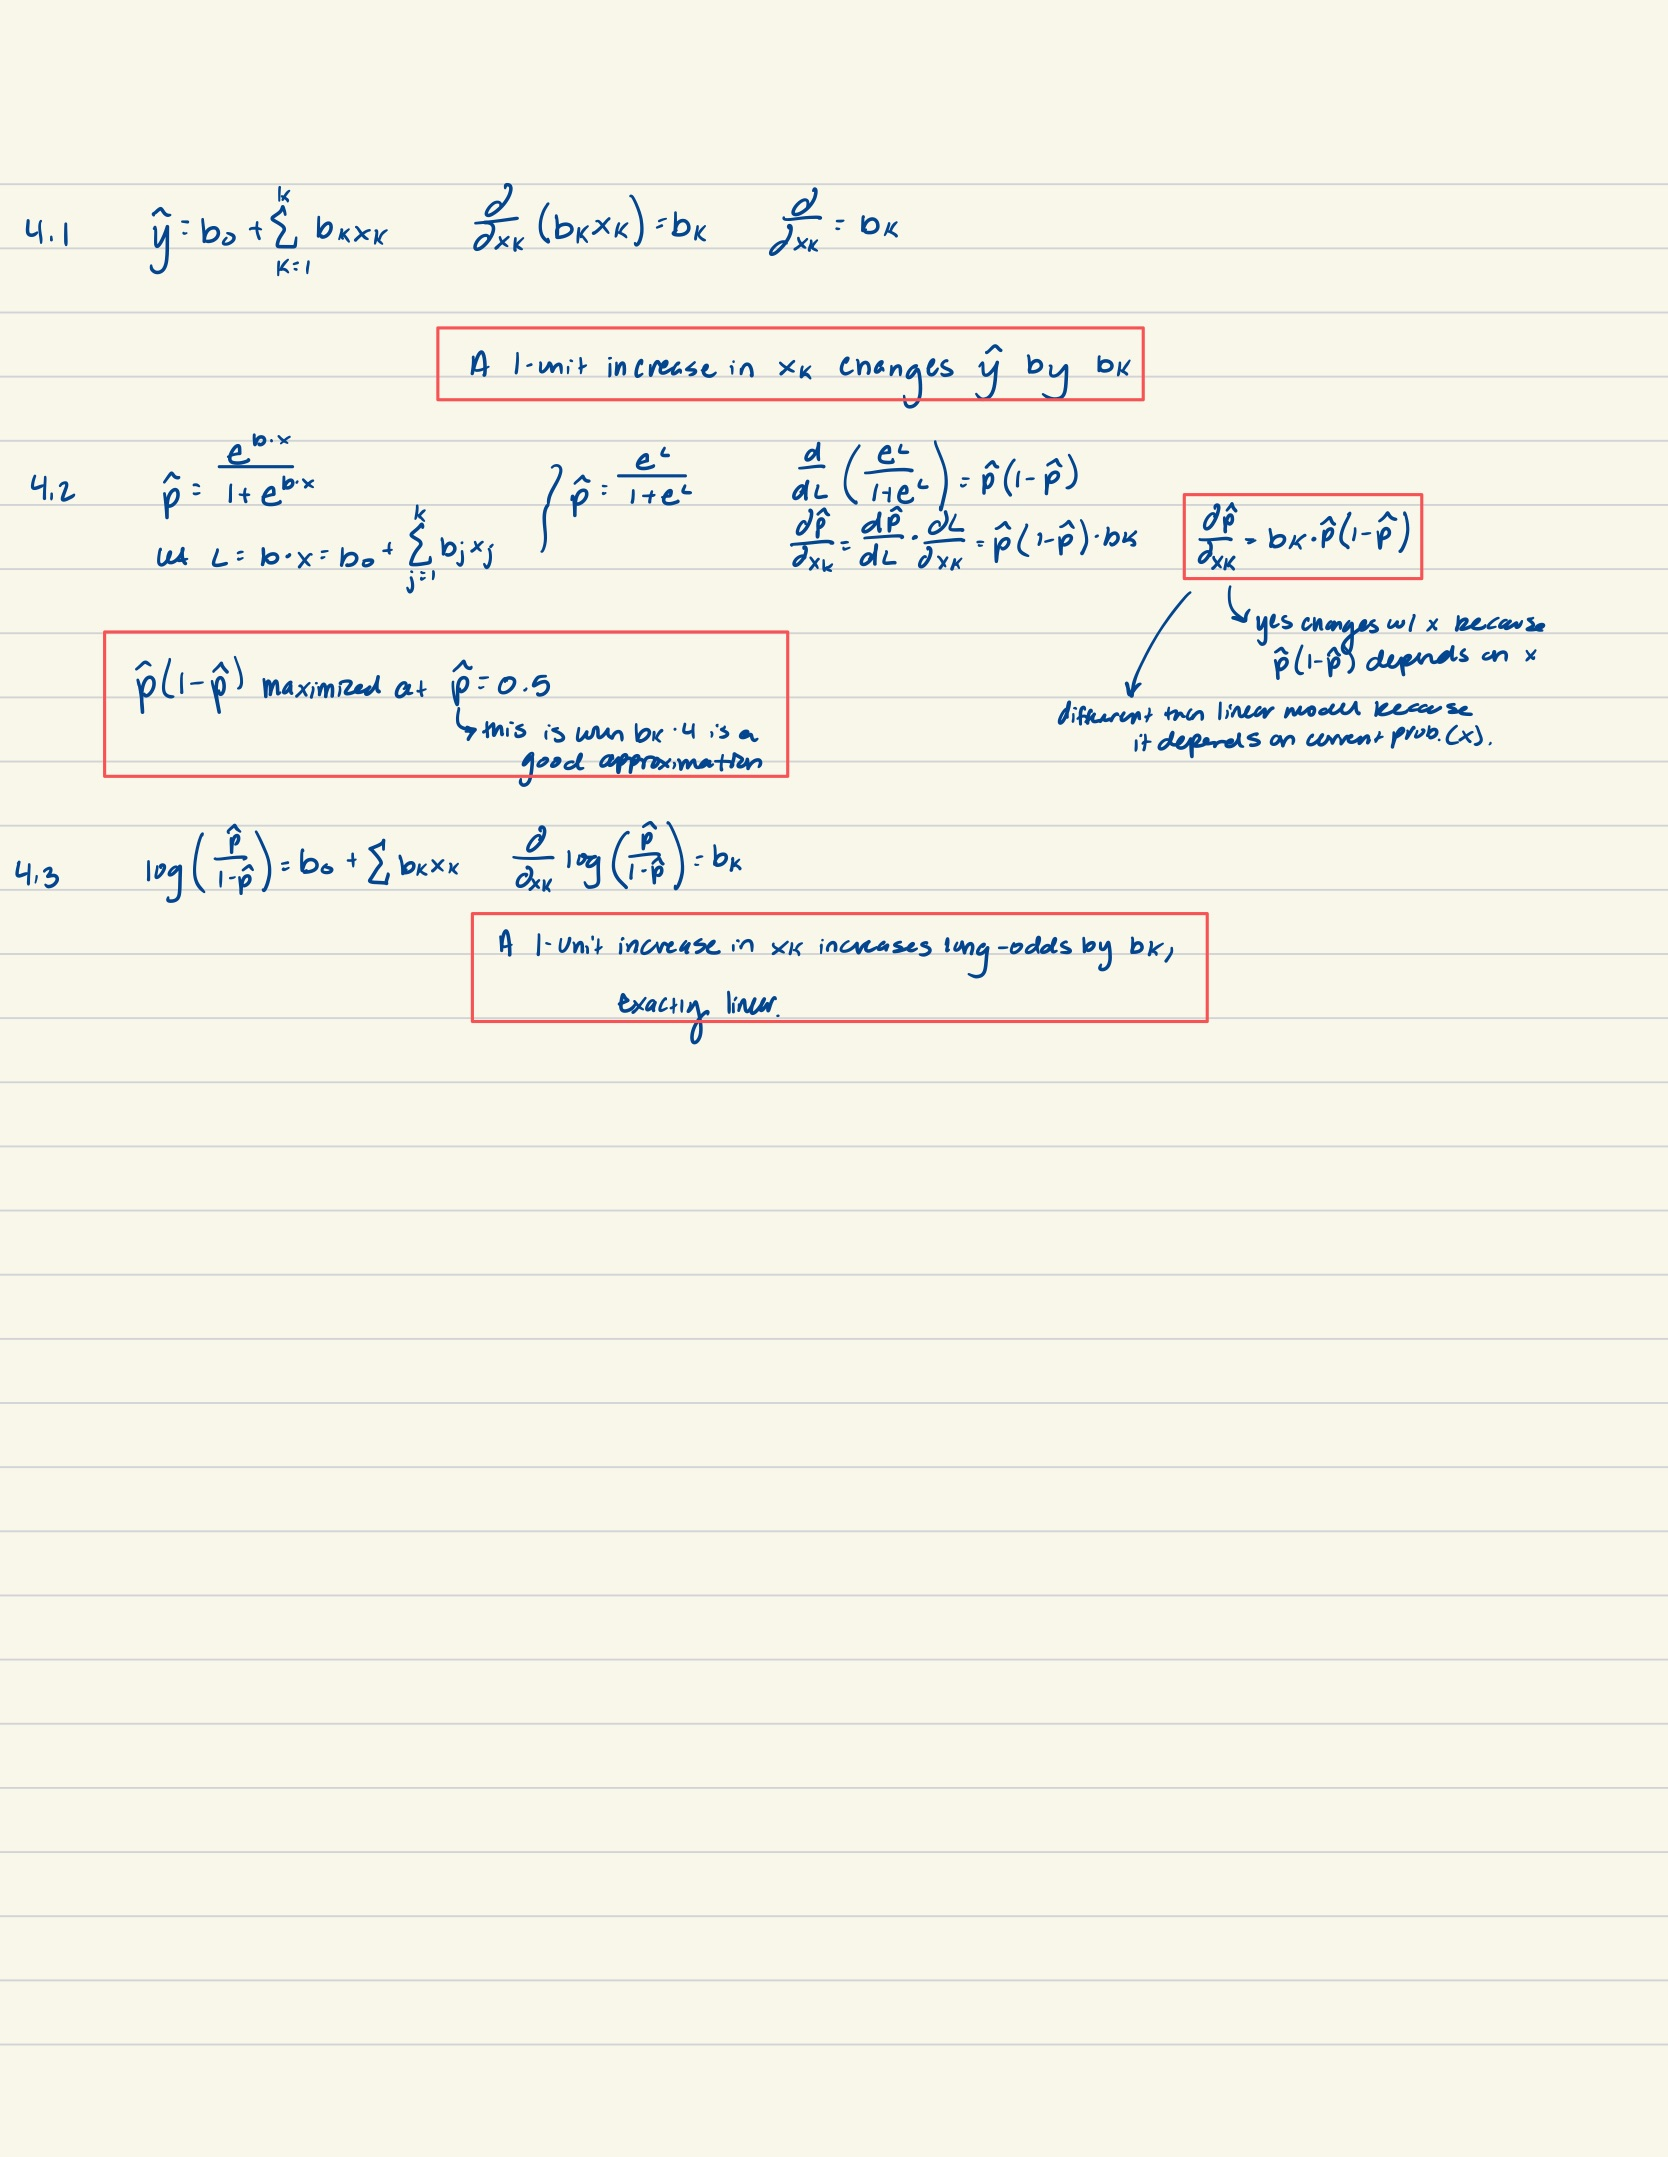